<a href="https://colab.research.google.com/github/luizkrawiec/estatistics/blob/main/teste_mann_whitney.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **teste Mann Whitney (soma de postos de Wilcoxon)**

Teste não paramétrico

Duas amostras independentes

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels
from statsmodels.stats.diagnostic import lilliefors
from scipy.stats import levene
from statsmodels.stats.weightstats import ztest

In [2]:
enem_sp = pd.read_csv('/content/enem_2019_tratado.csv', sep=',', encoding='iso-8859-1')

In [3]:
enem_sp.head()

,NU_INSCRICAO,NO_MUNICIPIO_RESIDENCIA,IDADE,SEXO,TP_ESTADO_CIVIL,RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,ESCOLA,CO_ESCOLA,...,NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,COMP1,COMP2,COMP3,COMP4,COMP5,NOTA_REDACAO,INTERNET
0,"1,90E+11",Santa Isabel,22,M,1,parda,1,1,não_respondeu,NaN,...,600.2,Inglês,1.0,160.0,200.0,180.0,200.0,200.0,940.0,Sim
1,"1,90E+11",São Paulo,17,F,1,parda,1,2,privada,15567761.0,...,731.8,Inglês,1.0,160.0,120.0,200.0,200.0,200.0,880.0,Não
2,"1,90E+11",São Bernardo do Campo,19,M,1,parda,1,2,pública,35904958.0,...,393.2,Espanhol,1.0,80.0,160.0,120.0,100.0,100.0,560.0,Sim
3,"1,90E+11",Embu-Guaçu,17,F,1,parda,1,2,pública,NaN,...,419.2,Inglês,1.0,120.0,120.0,120.0,120.0,80.0,560.0,Sim
4,"1,90E+11",Guarulhos,23,F,1,branca,1,1,não_respondeu,NaN,...,796.1,Inglês,1.0,160.0,200.0,180.0,180.0,160.0,880.0,Sim


## **Objetivo:**

Analisar a diferença entre as medianas de mulheres e homens para a nota de um dos componentes de redação do colégio x.

In [4]:
colegiox =enem_sp.loc[enem_sp.CO_ESCOLA == 35017632]

In [5]:
colegiox.shape

(41, 28)

In [6]:
colegiox.head()

,NU_INSCRICAO,NO_MUNICIPIO_RESIDENCIA,IDADE,SEXO,TP_ESTADO_CIVIL,RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,ESCOLA,CO_ESCOLA,...,NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,COMP1,COMP2,COMP3,COMP4,COMP5,NOTA_REDACAO,INTERNET
37,"1,90E+11",Águas de Lindóia,18,M,1,branca,1,2,pública,35017632.0,...,537.1,Inglês,1.0,120.0,40.0,40.0,120.0,20.0,340.0,Sim
44,"1,90E+11",Águas de Lindóia,17,F,1,parda,1,2,pública,35017632.0,...,451.9,Inglês,1.0,140.0,120.0,140.0,160.0,160.0,720.0,Não
52,"1,90E+11",Águas de Lindóia,17,F,1,branca,1,2,pública,35017632.0,...,506.4,Espanhol,1.0,120.0,120.0,120.0,120.0,80.0,560.0,Não
65,"1,90E+11",Águas de Lindóia,17,M,1,parda,1,2,pública,35017632.0,...,59.5,Inglês,1.0,120.0,120.0,120.0,120.0,40.0,520.0,Sim
79,"1,90E+11",Águas de Lindóia,18,F,1,branca,1,2,pública,35017632.0,...,510.6,Espanhol,1.0,120.0,120.0,120.0,140.0,140.0,640.0,Sim


In [7]:
colegiox_mulher = colegiox.loc[colegiox.SEXO == 'F']

In [8]:
colegiox_mulher.head()

,NU_INSCRICAO,NO_MUNICIPIO_RESIDENCIA,IDADE,SEXO,TP_ESTADO_CIVIL,RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,ESCOLA,CO_ESCOLA,...,NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,COMP1,COMP2,COMP3,COMP4,COMP5,NOTA_REDACAO,INTERNET
44,"1,90E+11",Águas de Lindóia,17,F,1,parda,1,2,pública,35017632.0,...,451.9,Inglês,1.0,140.0,120.0,140.0,160.0,160.0,720.0,Não
52,"1,90E+11",Águas de Lindóia,17,F,1,branca,1,2,pública,35017632.0,...,506.4,Espanhol,1.0,120.0,120.0,120.0,120.0,80.0,560.0,Não
79,"1,90E+11",Águas de Lindóia,18,F,1,branca,1,2,pública,35017632.0,...,510.6,Espanhol,1.0,120.0,120.0,120.0,140.0,140.0,640.0,Sim
84,"1,90E+11",Águas de Lindóia,19,F,1,branca,1,2,pública,35017632.0,...,420.6,Espanhol,1.0,140.0,40.0,40.0,120.0,20.0,360.0,Sim
91,"1,90E+11",Águas de Lindóia,18,F,1,branca,1,2,pública,35017632.0,...,537.9,Inglês,1.0,120.0,120.0,120.0,120.0,80.0,560.0,Sim


In [9]:
colegiox_mulher.shape

(28, 28)

In [10]:
colegiox_homem = colegiox.loc[colegiox.SEXO == 'M']

In [11]:
colegiox_homem.shape

(13, 28)

In [12]:
colegiox_homem.head()

,NU_INSCRICAO,NO_MUNICIPIO_RESIDENCIA,IDADE,SEXO,TP_ESTADO_CIVIL,RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,ESCOLA,CO_ESCOLA,...,NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,COMP1,COMP2,COMP3,COMP4,COMP5,NOTA_REDACAO,INTERNET
37,"1,90E+11",Águas de Lindóia,18,M,1,branca,1,2,pública,35017632.0,...,537.1,Inglês,1.0,120.0,40.0,40.0,120.0,20.0,340.0,Sim
65,"1,90E+11",Águas de Lindóia,17,M,1,parda,1,2,pública,35017632.0,...,59.5,Inglês,1.0,120.0,120.0,120.0,120.0,40.0,520.0,Sim
85,"1,90E+11",Águas de Lindóia,18,M,1,branca,1,2,pública,35017632.0,...,508.2,Espanhol,1.0,140.0,140.0,120.0,160.0,120.0,680.0,Sim
108151,"1,90E+11",Águas de Lindóia,18,M,1,branca,1,2,pública,35017632.0,...,705.3,Inglês,1.0,140.0,160.0,120.0,140.0,100.0,660.0,Sim
182519,"1,90E+11",Águas de Lindóia,17,M,1,parda,1,2,pública,35017632.0,...,480.9,Espanhol,1.0,100.0,120.0,100.0,100.0,100.0,520.0,Sim


## **Analise de valores missing**

In [13]:
colegiox.isnull().sum()

NU_INSCRICAO               0
NO_MUNICIPIO_RESIDENCIA    0
IDADE                      0
SEXO                       0
TP_ESTADO_CIVIL            0
RACA                       0
TP_NACIONALIDADE           0
TP_ST_CONCLUSAO            0
ESCOLA                     0
CO_ESCOLA                  0
NO_MUNICIPIO_ESC           0
TP_PRESENCA_CN             0
TP_PRESENCA_CH             0
TP_PRESENCA_LC             0
TP_PRESENCA_MT             0
NOTA_CN                    0
NOTA_CH                    0
NOTA_LC                    0
NOTA_MT                    0
TP_LINGUA                  0
TP_STATUS_REDACAO          0
COMP1                      0
COMP2                      0
COMP3                      0
COMP4                      0
COMP5                      0
NOTA_REDACAO               0
INTERNET                   0
dtype: int64

# **Analisar Normalidade**
Critérios:

Nível de Significância de 0,05 ou 5% (MAIS UTILIZADO)

Quando p > 0,05 (distribuição normal).

In [14]:
#teste shapiro-Wilk - matemática
stats.shapiro(colegiox_mulher['NOTA_MT'])

ShapiroResult(statistic=0.7194505929946899, pvalue=5.430648343462963e-06)

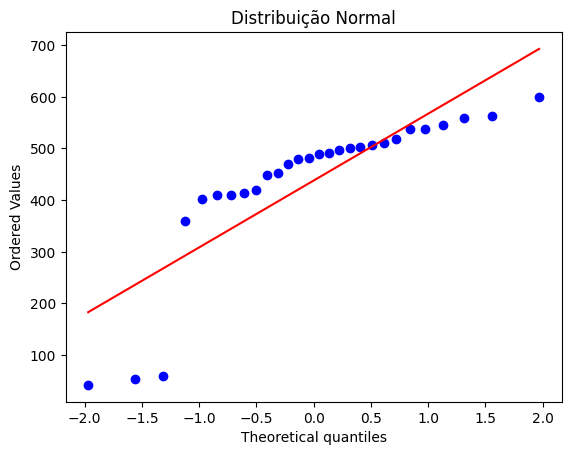

In [15]:
stats.probplot(colegiox_mulher['NOTA_MT'], dist='norm', plot=plt)
plt.title('Distribuição Normal')
plt.show()

In [16]:
#teste shapiro-Wilk - matematica
stats.shapiro(colegiox_homem['NOTA_MT'])

ShapiroResult(statistic=0.8659597635269165, pvalue=0.04620101675391197)

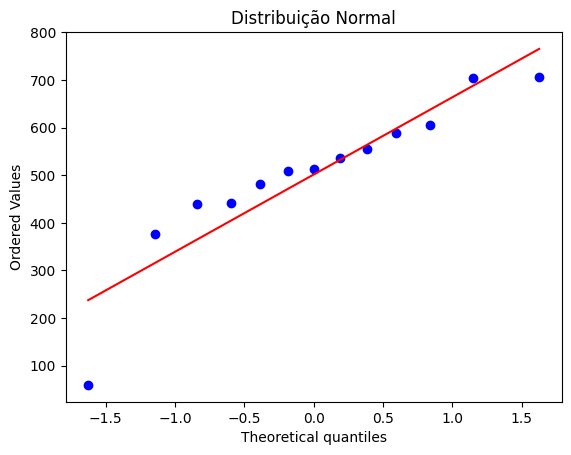

In [17]:
stats.probplot(colegiox_homem['NOTA_MT'], dist='norm', plot=plt)
plt.title('Distribuição Normal')
plt.show()

In [20]:
#teste shapiro-Wilk - ciencias da natureza
stats.shapiro(colegiox_homem['NOTA_CN'])

ShapiroResult(statistic=0.7647997736930847, pvalue=0.0026814276352524757)

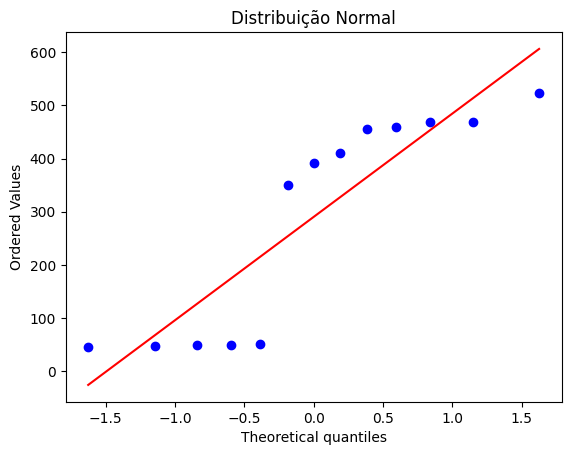

In [21]:
stats.probplot(colegiox_homem['NOTA_CN'], dist='norm', plot=plt)
plt.title('Distribuição Normal')
plt.show()

In [18]:
#teste shapiro-Wilk - ciencias da natureza
stats.shapiro(colegiox_mulher['NOTA_CN'])

ShapiroResult(statistic=0.7065988779067993, pvalue=3.536293434081017e-06)

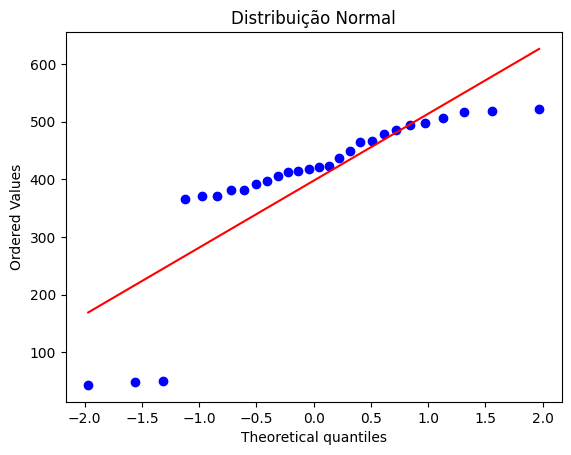

In [19]:
stats.probplot(colegiox_mulher['NOTA_CN'], dist='norm', plot=plt)
plt.title('Distribuição Normal')
plt.show()

# **Teste Mann Whitney**

comparação das medianas das notas homens e mulheres do colégio x.

Ho = Não há diferença entre as medianas das notas de homens e mulheres: p>0.05

Ha = Há diferença entre as medianas das notas entre homens e mulheres: p<=0.05

In [22]:
stat, p =  stats.mannwhitneyu(colegiox_mulher['NOTA_MT'], colegiox_homem['NOTA_MT'])
print('Estatistica de teste: {}'.format(stat.round(2)))
print('p-valor: {}'.format(p))

Estatistica de teste: 127.0
p-valor: 0.12678483629218537


In [24]:
stat, p =  stats.mannwhitneyu(colegiox_mulher.NOTA_CN, colegiox_homem.NOTA_CN)
print('Estatistica de teste: {}'.format(stat.round(2)))
print('p-valor: {}'.format(p))

Estatistica de teste: 228.0
p-valor: 0.20239601597295886


In [ ]:
colegiox_mulher.NOTA_MT.describe()

In [ ]:
colegiox_homem.NOTA_MT.describe()

In [ ]:
colegiox_mulher.NOTA_CN.describe()

In [ ]:
colegiox_homem.NOTA_CN.describe()